In [42]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name() # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

### 단일 디시전 트리(그냥 결정 트리)

In [44]:
# make_moons 데이터 불러오기

X, y = make_moons(n_samples = 1000, noise = 0.3, random_state = 42)

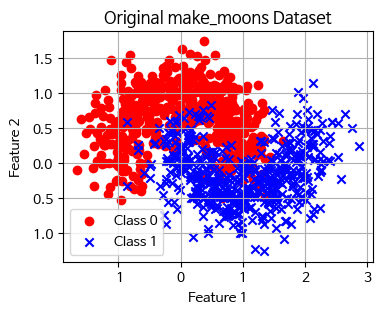

In [45]:
# 데이터셋 시각화 (어떻게 생겼는지 눈으로 확인)

plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c = 'red', marker = 'o', label = 'Class 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c = 'blue', marker = 'x', label = 'Class 1')
plt.title('Original make_moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [58]:
dt_clf = DecisionTreeClassifier(max_depth = 7)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7)

In [59]:
y_pred_dt = dt_clf.predict(X_test)

In [60]:
# 정확도 계산

accuracy_dt = accuracy_score(y_test, y_pred_dt)

accuracy_dt

0.9166666666666666

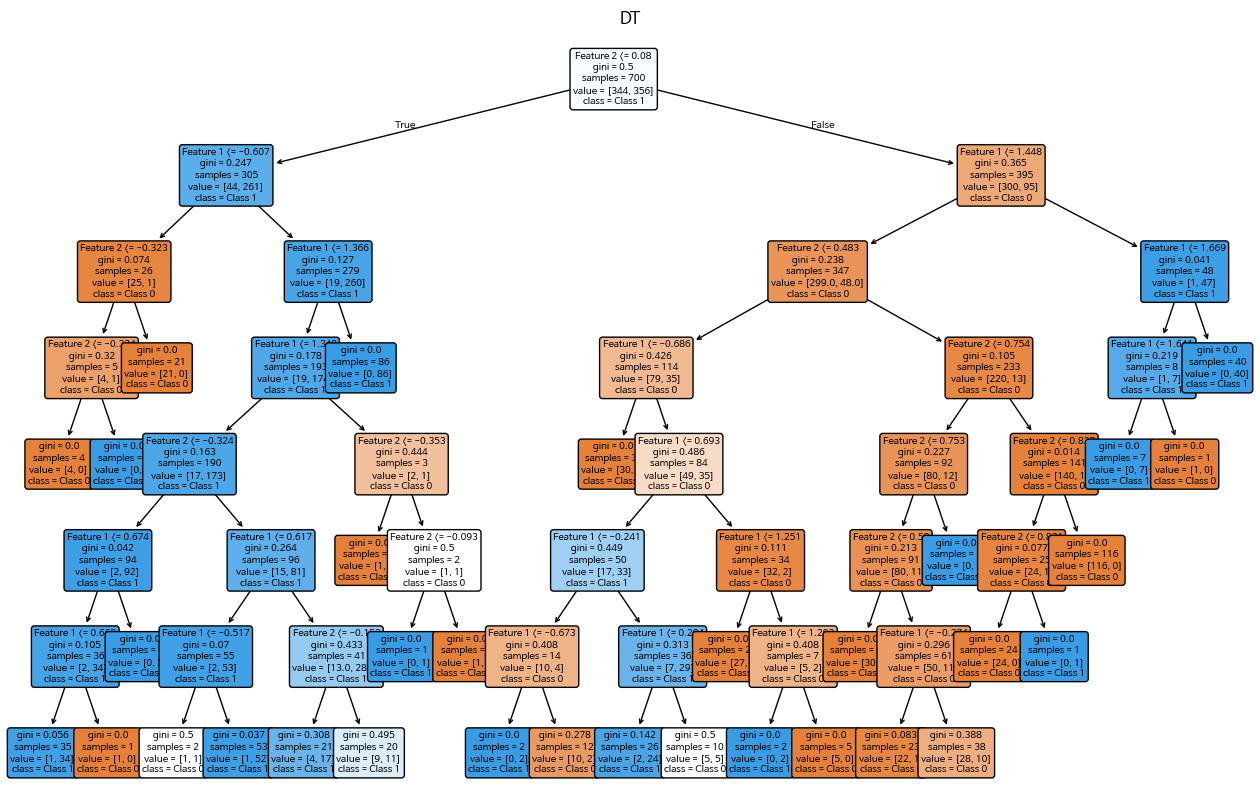

In [61]:
from sklearn.tree import plot_tree

plt.figure(figsize = (16, 10))
plot_tree(
    dt_clf,
    filled = True,
    rounded = True,
    feature_names = ['Feature 1', 'Feature 2'],
    class_names = ['Class 0', 'Class 1'],
    fontsize = 7
)

plt.title('DT')
plt.show()

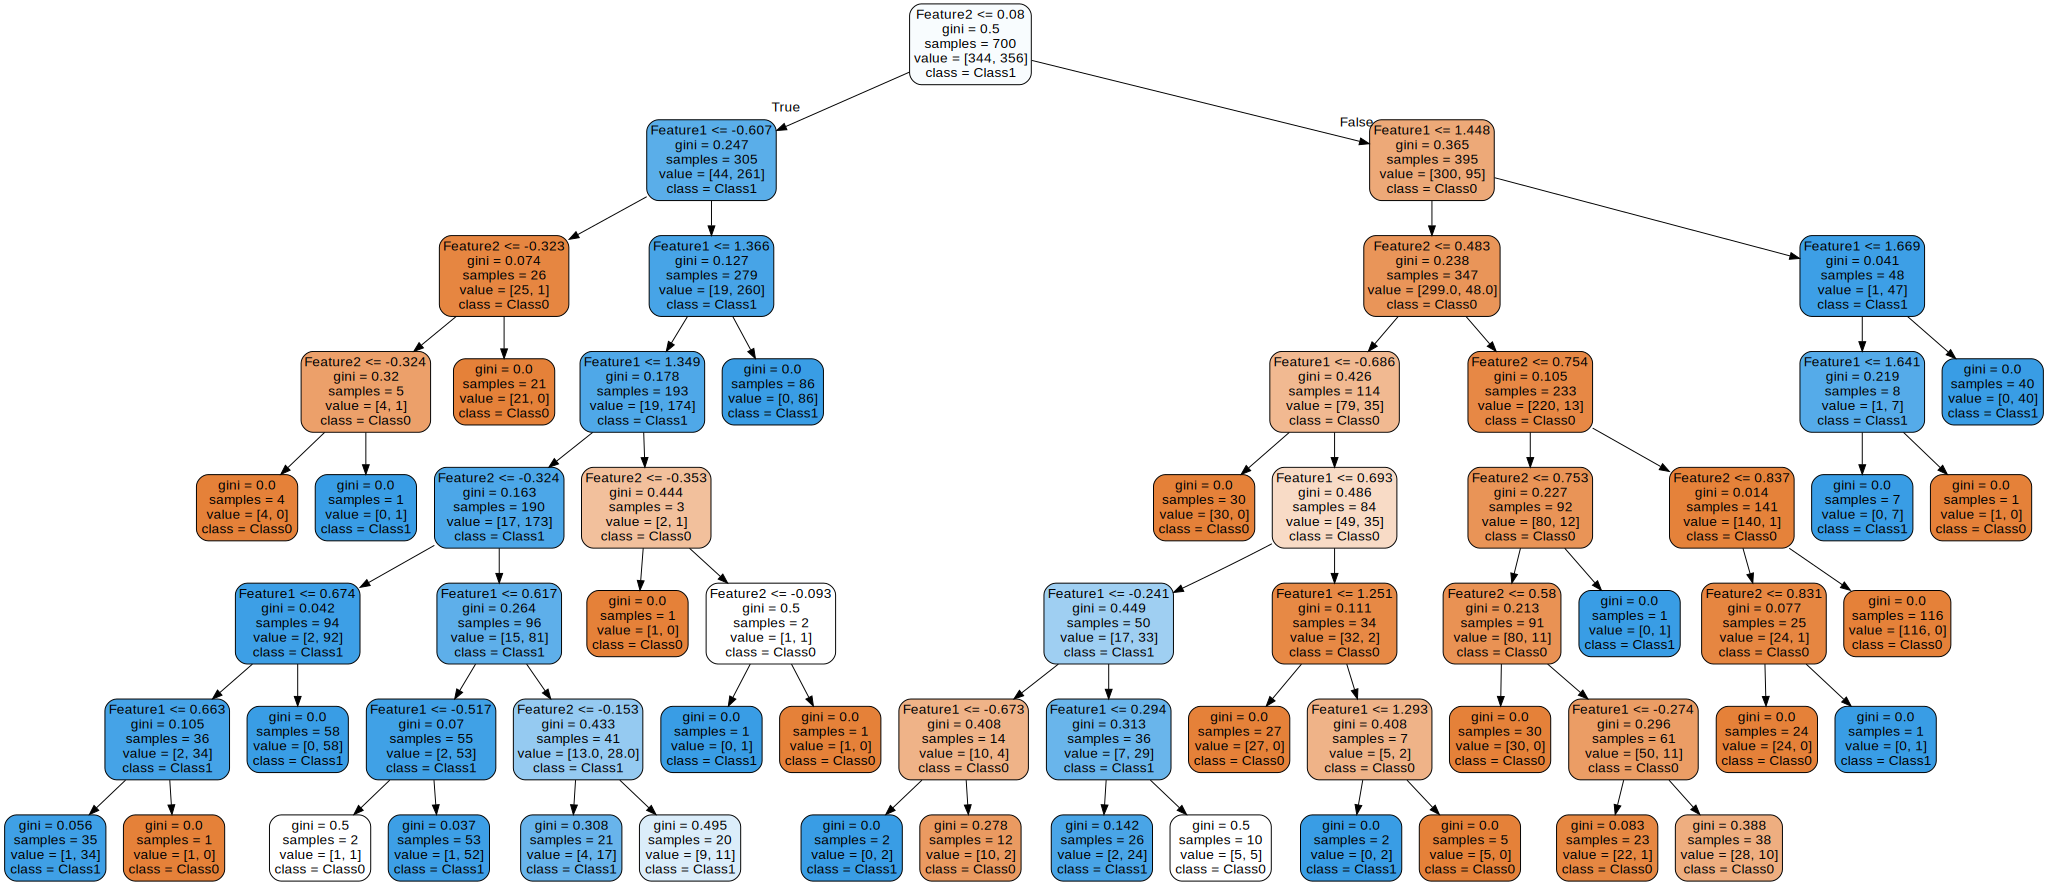

In [62]:
# 추가 - 보기 좋은 시각화

from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_clf,
    feature_names = ['Feature1', 'Feature2'],
    class_names = ['Class0', 'Class1'],
    filled = True,
    rounded = True
)

graph = graphviz.Source(dot_data)

graph

In [63]:
# 산점도 시각화할 함수 정의

def plot_decision_boundary(model, X, y, title = "Decision Boundary"):
    # 컬러맵 정의
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])  # 배경 색
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])   # 점 색

    # 그리드 영역 설정
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 모델로 예측한 결정 경계
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 시각화
    plt.figure(figsize = (8, 6))
    plt.contourf(xx, yy, Z, cmap = cmap_light)  # 결정 경계 색
    plt.scatter(X[:, 0], X[:, 1], c = y, cmap = cmap_bold, edgecolor = 'k', s = 30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

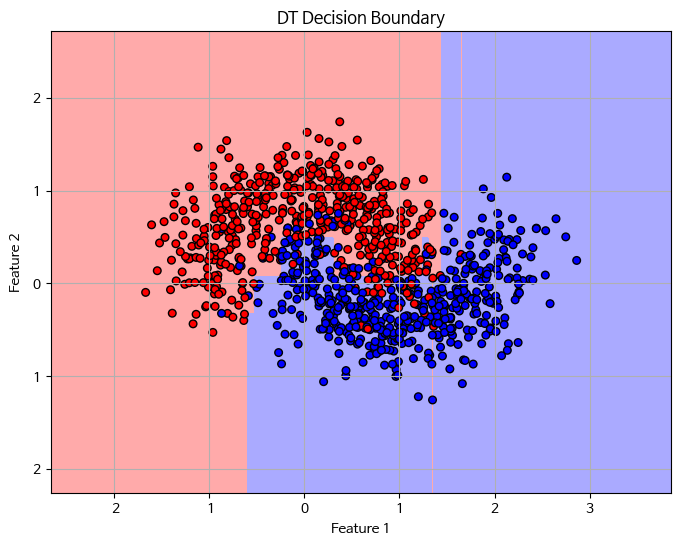

In [64]:
plot_decision_boundary(dt_clf, X, y, title = "DT Decision Boundary")

### 랜덤 포레스트 실습

In [69]:
# n_estimators 아주 중요
rf_clf = RandomForestClassifier(n_estimators = 100, max_depth = 7, n_jobs = -1)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, n_jobs=-1)

In [70]:
y_pred_rf = rf_clf.predict(X_test)

In [71]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_rf

0.9166666666666666

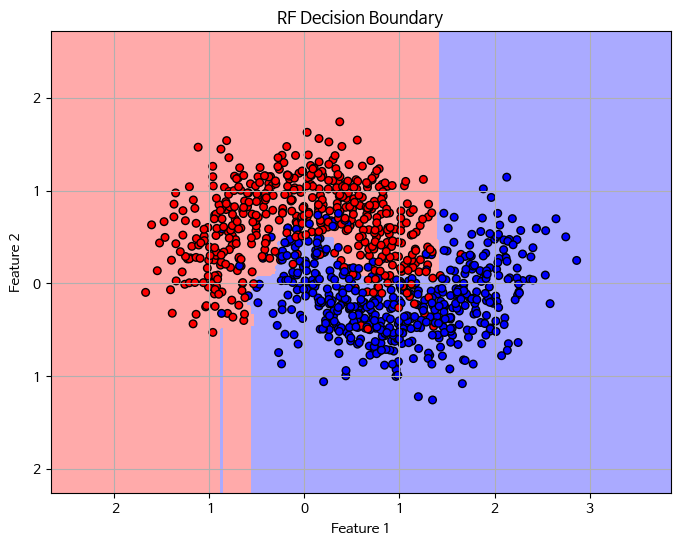

In [72]:
plot_decision_boundary(rf_clf, X, y, title = 'RF Decision Boundary')